# Notebook 2: Text Preprocessing, TF-IDF Feature Engineering, and Baseline Ticket Routing Models

## Project
**Automating Support Ticket Routing with NLP**

## Notebook objective
This notebook transforms the cleaned support ticket text into machine-learning-ready features using TF-IDF and trains multiple baseline classification models to predict the correct routing team.

## Why this notebook matters
Once support tickets have been cleaned, the next step is to convert free text into numerical representations that machine learning models can understand.

This notebook builds the first predictive routing system by:
- loading the cleaned ticket dataset
- preparing the target labels and input text
- splitting the data into training and test sets
- applying TF-IDF vectorization
- training multiple baseline classifiers
- comparing model performance using appropriate metrics
- selecting and saving the best-performing pipeline

## Main prediction task
Predict the correct `routed_team` from each ticket's text content.

## Models compared
The following baseline models are evaluated:
- Multinomial Naive Bayes
- Logistic Regression
- Linear Support Vector Classifier
- Random Forest

## Evaluation focus
Because the ticket classes are not perfectly balanced, this notebook places strong emphasis on:
- Macro F1-score
- Weighted F1-score
- Accuracy
- Per-class performance

In [23]:
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 140)

SEED = 42
np.random.seed(SEED)

## Load the cleaned dataset

We use the cleaned dataset produced in Notebook 1.  
This dataset already contains:
- standardised categorical fields
- cleaned ticket text
- reduced duplicates
- text-length features

The key field used in this notebook is:
- `ticket_text` for model input
- `routed_team` for the classification target

In [24]:
BASE_DIR = Path.cwd()
PROCESSED_DIR = BASE_DIR / "data" / "processed"
MODELS_DIR = BASE_DIR / "models"
RESULTS_DIR = BASE_DIR / "results"
FIGURES_DIR = BASE_DIR / "figures"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

clean_path = PROCESSED_DIR / "support_tickets_clean.csv"
df = pd.read_csv(clean_path)

print("Loaded file:", clean_path)
print("Dataset shape:", df.shape)
df.head()

Loaded file: C:\Users\Owen\Documents\Hertsfordshire\Projects\Automating Support Ticket Routing with NLP\data\processed\support_tickets_clean.csv
Dataset shape: (3684, 15)


,ticket_id,created_at,channel,customer_tier,language,product_area,subject,description,routed_team,secondary_issue_team,priority,status,ticket_text,text_length_chars,text_length_words
0,TKT-000909,2025-01-01 02:04:29,email,Basic,Spanish,Web App,Follow-up on my previous isue,Can someone help with this? Authentication is not going through on my side. It involves web app on my side. I am using the service on mo...,Account Access,Unknown,Low,Pending,Follow-up on my previous isue Can someone help with this? Authentication is not going through on my side. It involves web app on my side...,179,33
1,TKT-002115,2025-01-01 02:33:29,web_form,Pro,English,Premium Device,Need help with Premium Device,"I think the wrong item was sent. In addition, i need my money back if this cannot be resolved. This happened shortly after I updated my ...",Orders & Delivery,Refunds & Returns,Medium,Open,"Need help with Premium Device I think the wrong item was sent. In addition, i need my money back if this cannot be resolved. This happen...",207,38
2,TKT-001362,2025-01-01 04:18:46,phone,Free,English,Premium Device,Question about Premium Device,This has become a problem for me. The package is missing and I need an update. It involves premium device on my side. This is becoming u...,Orders & Delivery,Unknown,Medium,Resolved,Question about Premium Device This has become a problem for me. The package is missing and I need an update. It involves premium device ...,172,31
3,TKT-001855,2025-01-01 06:50:10,email,Basic,English,Subscription Plan,Problem with Subscription Plan,I think I was charged incorrectly for this. It involves subscription plan on my side. This may also be related becau...,Billing,Account Access,Medium,Resolved,Problem with Subscription Plan I think I was charged incorrectly for this. It involves subscription plan on my side. This may also be re...,323,56
4,TKT-001842,2025-01-01 09:18:59,email,Basic,English,Unknown,Issue with failed export,"Hi team, This was working before but now it keeps failing. This is quite frustrating. Please let me know what I should do next.",Technical Support,Unknown,Medium,Resolved,"Issue with failed export Hi team, This was working before but now it keeps failing. This is quite frustrating. Please let me know what I...",152,28


## Inspect the dataset and confirm required fields

Before training, we confirm that the two core columns needed for text classification are present:
- `ticket_text`
- `routed_team`

We also inspect class balance because this affects how we evaluate model performance.

In [25]:
required_cols = ["ticket_text", "routed_team"]

missing_required = [col for col in required_cols if col not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

print("Available columns:")
print(df.columns.tolist())

print("\nMissing values in required columns:")
print(df[required_cols].isna().sum())

print("\nClass distribution:")
display(df["routed_team"].value_counts())

print("\nClass distribution (%):")
display((df["routed_team"].value_counts(normalize=True) * 100).round(2))

Available columns:
['ticket_id', 'created_at', 'channel', 'customer_tier', 'language', 'product_area', 'subject', 'description', 'routed_team', 'secondary_issue_team', 'priority', 'status', 'ticket_text', 'text_length_chars', 'text_length_words']

Missing values in required columns:
ticket_text    0
routed_team    0
dtype: int64

Class distribution:


routed_team
Technical Support    896
Billing              600
Refunds & Returns    587
Orders & Delivery    554
Account Access       538
Product Inquiry      509
Name: count, dtype: int64


Class distribution (%):


routed_team
Technical Support    24.32
Billing              16.29
Refunds & Returns    15.93
Orders & Delivery    15.04
Account Access       14.60
Product Inquiry      13.82
Name: proportion, dtype: float64

## Prepare the modeling dataset

For this first routing baseline, we use the ticket text only.

### Input
- `ticket_text`

### Target
- `routed_team`

Using text-only features first gives a clean NLP baseline.  
Additional metadata such as `channel`, `customer_tier`, and `product_area` can be added later if needed.

In [26]:
model_df = df[["ticket_text", "routed_team"]].copy()

model_df["ticket_text"] = model_df["ticket_text"].fillna("").astype(str).str.strip()
model_df["routed_team"] = model_df["routed_team"].astype(str).str.strip()

# Remove any empty-text rows just in case
model_df = model_df[model_df["ticket_text"].str.len() > 0].copy()

X = model_df["ticket_text"]
y = model_df["routed_team"]

print("Modeling shape:", model_df.shape)
print("\nUnique classes:", y.nunique())
print(sorted(y.unique()))

Modeling shape: (3684, 2)

Unique classes: 6
['Account Access', 'Billing', 'Orders & Delivery', 'Product Inquiry', 'Refunds & Returns', 'Technical Support']


## Train-test split

We split the data into:
- training set: used for model fitting and cross-validation
- test set: used only for final evaluation

A stratified split is used to preserve the class distribution across both sets.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

print("\nTraining class distribution (%):")
display((y_train.value_counts(normalize=True) * 100).round(2).sort_index())

print("\nTest class distribution (%):")
display((y_test.value_counts(normalize=True) * 100).round(2).sort_index())

Training samples: 2947
Test samples: 737

Training class distribution (%):


routed_team
Account Access       14.59
Billing              16.29
Orders & Delivery    15.03
Product Inquiry      13.81
Refunds & Returns    15.95
Technical Support    24.33
Name: proportion, dtype: float64


Test class distribution (%):


routed_team
Account Access       14.65
Billing              16.28
Orders & Delivery    15.06
Product Inquiry      13.84
Refunds & Returns    15.88
Technical Support    24.29
Name: proportion, dtype: float64

## Define the TF-IDF vectorizer and baseline model pipelines

TF-IDF converts ticket text into weighted numerical features based on how informative each word or phrase is across the corpus.

### Vectorization choices
- lowercase conversion
- stop-word removal
- unigrams and bigrams
- minimum document frequency threshold

### Models
We compare several common text classification baselines:
- Multinomial Naive Bayes
- Logistic Regression
- Linear SVC
- Random Forest

In [28]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True
)

pipelines = {
    "MultinomialNB": Pipeline([
        ("tfidf", tfidf),
        ("model", MultinomialNB())
    ]),
    "LogisticRegression": Pipeline([
        ("tfidf", tfidf),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=SEED
        ))
    ]),
    "LinearSVC": Pipeline([
        ("tfidf", tfidf),
        ("model", LinearSVC(
            class_weight="balanced",
            random_state=SEED
        ))
    ]),
    "RandomForest": Pipeline([
        ("tfidf", tfidf),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            random_state=SEED,
            n_jobs=-1
        ))
    ])
}

## Cross-validate the baseline models on the training set

Before evaluating on the test set, we compare the models using stratified cross-validation on the training data.

### Why cross-validation?
Cross-validation provides a more stable estimate of model performance than a single split.

### Metrics used
- Accuracy
- Macro F1
- Weighted F1

For this routing task, **Macro F1** is especially important because it treats each class equally, even when class sizes differ.

In [29]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

scoring = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted"
}

cv_results = []

for model_name, pipeline in pipelines.items():
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    cv_results.append({
        "model": model_name,
        "cv_accuracy_mean": scores["test_accuracy"].mean(),
        "cv_accuracy_std": scores["test_accuracy"].std(),
        "cv_f1_macro_mean": scores["test_f1_macro"].mean(),
        "cv_f1_macro_std": scores["test_f1_macro"].std(),
        "cv_f1_weighted_mean": scores["test_f1_weighted"].mean(),
        "cv_f1_weighted_std": scores["test_f1_weighted"].std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(
    by="cv_f1_macro_mean",
    ascending=False
).reset_index(drop=True)

cv_results_df_rounded = cv_results_df.copy()
metric_cols = [col for col in cv_results_df_rounded.columns if col != "model"]
cv_results_df_rounded[metric_cols] = cv_results_df_rounded[metric_cols].round(4)

display(cv_results_df_rounded)

,model,cv_accuracy_mean,cv_accuracy_std,cv_f1_macro_mean,cv_f1_macro_std,cv_f1_weighted_mean,cv_f1_weighted_std
0,LinearSVC,0.9525,0.0048,0.9507,0.0051,0.9525,0.0047
1,LogisticRegression,0.9111,0.0079,0.9079,0.0079,0.9110,0.0079
2,MultinomialNB,0.8921,0.0087,0.8880,0.0084,0.8912,0.0088
3,RandomForest,0.8507,0.0095,0.8430,0.0101,0.8490,0.0098


## Train each model on the full training set and evaluate on the test set

After cross-validation, each model is fitted on the full training set and evaluated on the held-out test set.

This gives a fair estimate of real-world performance on unseen tickets.

In [30]:
test_results = []
fitted_models = {}

for model_name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    fitted_models[model_name] = pipeline

    test_results.append({
        "model": model_name,
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_f1_macro": f1_score(y_test, y_pred, average="macro"),
        "test_f1_weighted": f1_score(y_test, y_pred, average="weighted")
    })

test_results_df = pd.DataFrame(test_results).sort_values(
    by="test_f1_macro",
    ascending=False
).reset_index(drop=True)

test_results_df_rounded = test_results_df.copy()
metric_cols = [col for col in test_results_df_rounded.columns if col != "model"]
test_results_df_rounded[metric_cols] = test_results_df_rounded[metric_cols].round(4)

display(test_results_df_rounded)

,model,test_accuracy,test_f1_macro,test_f1_weighted
0,LinearSVC,0.9620,0.9620,0.9622
1,LogisticRegression,0.9281,0.9271,0.9280
2,MultinomialNB,0.8928,0.8912,0.8927
3,RandomForest,0.8453,0.8409,0.8439


## Compare cross-validation and test performance

This side-by-side comparison helps us see:
- whether the leading model is consistent across training and test evaluation
- whether performance is stable
- whether any model appears to overfit

In [31]:
comparison_df = cv_results_df.merge(test_results_df, on="model", how="left")

comparison_df_rounded = comparison_df.copy()
metric_cols = [col for col in comparison_df_rounded.columns if col != "model"]
comparison_df_rounded[metric_cols] = comparison_df_rounded[metric_cols].round(4)

display(comparison_df_rounded)

comparison_path = RESULTS_DIR / "baseline_model_comparison.csv"
comparison_df_rounded.to_csv(comparison_path, index=False)

print("Saved model comparison to:", comparison_path)

,model,cv_accuracy_mean,cv_accuracy_std,cv_f1_macro_mean,cv_f1_macro_std,cv_f1_weighted_mean,cv_f1_weighted_std,test_accuracy,test_f1_macro,test_f1_weighted
0,LinearSVC,0.9525,0.0048,0.9507,0.0051,0.9525,0.0047,0.9620,0.9620,0.9622
1,LogisticRegression,0.9111,0.0079,0.9079,0.0079,0.9110,0.0079,0.9281,0.9271,0.9280
2,MultinomialNB,0.8921,0.0087,0.8880,0.0084,0.8912,0.0088,0.8928,0.8912,0.8927
3,RandomForest,0.8507,0.0095,0.8430,0.0101,0.8490,0.0098,0.8453,0.8409,0.8439


Saved model comparison to: C:\Users\Owen\Documents\Hertsfordshire\Projects\Automating Support Ticket Routing with NLP\results\baseline_model_comparison.csv


## Select the best-performing model

The best model is selected using **test Macro F1-score**.  
This is a suitable primary metric because it rewards balanced performance across all routing classes.

In [32]:
best_model_name = test_results_df.iloc[0]["model"]
best_pipeline = fitted_models[best_model_name]

print("Best model selected:", best_model_name)

Best model selected: LinearSVC


## Detailed evaluation of the best model

For the selected model, we now produce:
- a classification report
- a confusion matrix
- saved prediction outputs

This provides both overall and class-specific performance insight.

In [33]:
y_pred_best = best_pipeline.predict(X_test)

best_accuracy = accuracy_score(y_test, y_pred_best)
best_f1_macro = f1_score(y_test, y_pred_best, average="macro")
best_f1_weighted = f1_score(y_test, y_pred_best, average="weighted")

print("Best model:", best_model_name)
print(f"Accuracy:     {best_accuracy:.4f}")
print(f"Macro F1:     {best_f1_macro:.4f}")
print(f"Weighted F1:  {best_f1_weighted:.4f}")

Best model: LinearSVC
Accuracy:     0.9620
Macro F1:     0.9620
Weighted F1:  0.9622


In [34]:
report_dict = classification_report(y_test, y_pred_best, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

report_df_rounded = report_df.round(4)
display(report_df_rounded)

report_path = RESULTS_DIR / "best_model_classification_report.csv"
report_df_rounded.to_csv(report_path)

print("Saved classification report to:", report_path)

,precision,recall,f1-score,support
Account Access,0.9369,0.9630,0.9498,108.000
Billing,0.9280,0.9667,0.9469,120.000
Orders & Delivery,0.9908,0.9730,0.9818,111.000
Product Inquiry,0.9429,0.9706,0.9565,102.000
Refunds & Returns,0.9912,0.9573,0.9739,117.000
Technical Support,0.9770,0.9497,0.9632,179.000
accuracy,0.9620,0.9620,0.9620,0.962
macro avg,0.9611,0.9634,0.9620,737.000
weighted avg,0.9628,0.9620,0.9622,737.000


Saved classification report to: C:\Users\Owen\Documents\Hertsfordshire\Projects\Automating Support Ticket Routing with NLP\results\best_model_classification_report.csv


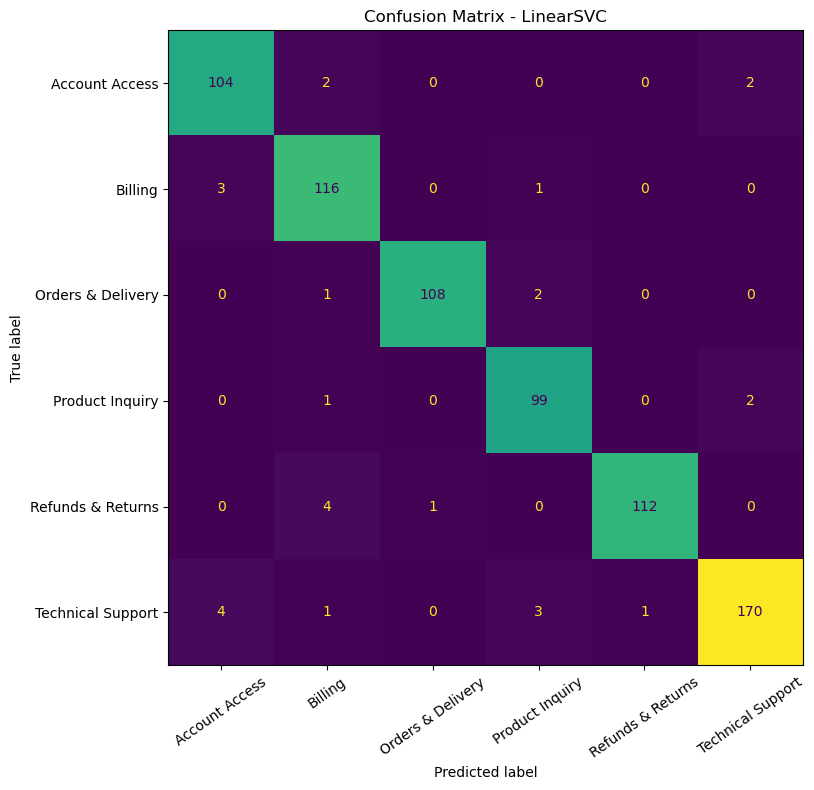

Saved confusion matrix figure to: C:\Users\Owen\Documents\Hertsfordshire\Projects\Automating Support Ticket Routing with NLP\figures\best_model_confusion_matrix.png


In [35]:
labels_sorted = sorted(y.unique())

cm = confusion_matrix(y_test, y_pred_best, labels=labels_sorted)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_sorted)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=35, colorbar=False)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()

cm_path = FIGURES_DIR / "best_model_confusion_matrix.png"
plt.savefig(cm_path, dpi=200)
plt.show()

print("Saved confusion matrix figure to:", cm_path)

##  Inspect example predictions

To make the model behaviour more interpretable, we inspect a sample of ticket texts alongside:
- the actual routed team
- the predicted routed team
- whether the prediction was correct

This is useful for manual error analysis.

In [36]:
predictions_df = pd.DataFrame({
    "ticket_text": X_test.values,
    "actual_team": y_test.values,
    "predicted_team": y_pred_best
})

predictions_df["is_correct"] = predictions_df["actual_team"] == predictions_df["predicted_team"]

predictions_path = RESULTS_DIR / "best_model_test_predictions.csv"
predictions_df.to_csv(predictions_path, index=False)

print("Saved test predictions to:", predictions_path)

display(predictions_df.sample(12, random_state=SEED).reset_index(drop=True))

Saved test predictions to: C:\Users\Owen\Documents\Hertsfordshire\Projects\Automating Support Ticket Routing with NLP\results\best_model_test_predictions.csv


,ticket_text,actual_team,predicted_team,is_correct
0,"Problem with Replacement Unit Hi, I need to return the item because it is not as expected. I only need a clear update on what is happening.",Refunds & Returns,Refunds & Returns,True
1,Issue with before purchase Can someone help with this? Can you explain how this feature works? This may also be related because i think ...,Product Inquiry,Product Inquiry,True
2,"Need an update on this issue I want to know the status of the return request. In addition, the invoice does not look right to me.",Refunds & Returns,Refunds & Returns,True
3,"NEED SUPPORT URGENTLY Hello, This was working before but now it keeps failing. It involves api on my side. This seems linked to my recen...",Technical Support,Technical Support,True
4,"double charge on my account Good morning, I think I was charged incorrectly for this. It involves customer portal on my side. In additio...",Billing,Billing,True
5,Problem with Invoice Portal again The renewal amount looks different from what I expected. This is becoming urgent.,Billing,Billing,True
6,"isue with recent order Hi, The export fails halfway through and I do not know why. This may also be related because i cannot sign in to ...",Technical Support,Technical Support,True
7,HELP NEEDED AGAIN I think I was charged incorrectly for this. It involves subscription plan on my side. This may also be related because...,Billing,Billing,True
8,"Problem with Subscription Plan Hi, This is more of a general product question. This is becoming urgent.",Product Inquiry,Product Inquiry,True
9,"Need an update on this issue Good morning, I need more information before making a decision. It involves premium device on my side. I on...",Product Inquiry,Product Inquiry,True


## Review common misclassifications

Misclassified examples are especially important because they show where ticket categories overlap.

For example:
- Billing vs Refunds & Returns
- Technical Support vs Account Access
- Product Inquiry vs Billing

These cases often reveal where text patterns are similar or ambiguous.

In [37]:
misclassified_df = predictions_df[~predictions_df["is_correct"]].copy()

print("Total misclassified tickets:", len(misclassified_df))
display(misclassified_df.head(15).reset_index(drop=True))

Total misclassified tickets: 28


,ticket_text,actual_team,predicted_team,is_correct
0,Issue not resolved,Billing,Account Access,False
1,"Problem with recent activity I need help with something. I cannot sign in to my account at the moment. Also, the page is not loading pro...",Account Access,Technical Support,False
2,NEED AN UPDATE ON THIS ISSUE,Orders & Delivery,Product Inquiry,False
3,"Problem with Data Export The export fails halfway through and I do not know why. Also, i need more information before making a decision....",Technical Support,Product Inquiry,False
4,"Hello, The product arrived damaged and I need help with next steps. Also, the amount shown on the invoice looks wrong. This seems linked...",Refunds & Returns,Billing,False
5,"billing issue on my account This was workng before but now it keeps failing. Also, the amount shown on the invoice looks wrong. I would ...",Technical Support,Billing,False
6,Follow-up on my previous issue,Billing,Account Access,False
7,"URGENT - Need support urgently I need to return the item because it is not as expected. In addition, the invoice does not look right to ...",Refunds & Returns,Billing,False
8,Follow-up on my previous issue,Billing,Account Access,False
9,Need help with Customer Portal,Account Access,Billing,False


## Save the best pipeline

To make the model reusable in later notebooks or in a Streamlit application, we save the full pipeline, including:
- TF-IDF vectorizer
- trained classifier

Saving the full pipeline allows future predictions to be made directly from raw ticket text without re-running the training steps.

In [38]:
model_path = MODELS_DIR / "best_ticket_routing_pipeline.joblib"
joblib.dump(best_pipeline, model_path)

print("Saved best model pipeline to:", model_path)

Saved best model pipeline to: C:\Users\Owen\Documents\Hertsfordshire\Projects\Automating Support Ticket Routing with NLP\models\best_ticket_routing_pipeline.joblib


## Summary of results

This notebook built the first predictive routing system using TF-IDF text features and baseline classifiers.

### What was completed
- loaded the cleaned support ticket dataset
- created a stratified train-test split
- converted ticket text into TF-IDF features
- trained multiple baseline classifiers
- compared performance using Macro F1, Weighted F1, and Accuracy
- selected the best-performing routing model
- saved the trained pipeline for reuse

### Why the result is useful
This provides a practical baseline for automated ticket triage.  
The selected model can now be used as the core routing engine for:
- downstream explainability analysis
- deployment in a Streamlit app
- integration into a broader service operations dashboard

In [39]:
summary_df = pd.DataFrame({
    "best_model": [best_model_name],
    "accuracy": [round(best_accuracy, 4)],
    "macro_f1": [round(best_f1_macro, 4)],
    "weighted_f1": [round(best_f1_weighted, 4)],
    "train_size": [len(X_train)],
    "test_size": [len(X_test)]
})

display(summary_df)

summary_path = RESULTS_DIR / "notebook2_summary.csv"
summary_df.to_csv(summary_path, index=False)

print("Saved notebook summary to:", summary_path)

,best_model,accuracy,macro_f1,weighted_f1,train_size,test_size
0,LinearSVC,0.962,0.962,0.9622,2947,737


Saved notebook summary to: C:\Users\Owen\Documents\Hertsfordshire\Projects\Automating Support Ticket Routing with NLP\results\notebook2_summary.csv
